In [ ]:
# SRSの黒点データを一年分さかのぼってExcelファイル化でき且つグラフ化する。
# 必要なライブラリをインストール（Google Colabなどで実行する場合）
try:
    import xlsxwriter
except ImportError:
    import subprocess
    print("XlsxWriterをインストールしています...")
    subprocess.check_call(["pip", "install", "XlsxWriter"])
    import xlsxwriter

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# データのURL
base_url = "https://sohoftp.nascom.nasa.gov/sdb/ydb/raw/selsis_regions/"

def parse_srs_file(text_content):
    """
    SRSファイルのテキストデータから日付と黒点相対数を計算する関数
    """
    lines = text_content.splitlines()

    date_val = None
    g = 0 # 黒点群の数
    f = 0 # 黒点の総数

    # セクションI（黒点あり）の中にいるかどうかのフラグ
    in_section_i = False

    for line in lines:
        # 1. 日付の抽出 (:Issued: 行を探す)
        if ":Issued:" in line:
            try:
                date_part = " ".join(line.split()[1:4]) # 2024 Apr 27
                date_val = pd.to_datetime(date_part)
            except:
                pass

        # 2. セクションの判定
        if line.startswith("I.  Regions with Sunspots") or line.startswith("I. Regions with Sunspots"):
            in_section_i = True
            continue

        # 次のセクションが始まったら終了
        if in_section_i and (line.startswith("IA.") or line.startswith("II.") or line.strip() == ""):
             if line.startswith("IA.") or line.startswith("II."):
                 in_section_i = False
                 break

        # 3. データの抽出と計算
        if in_section_i:
            parts = line.split()
            # データ行の特徴（数字で始まり、要素数が多い）
            if len(parts) > 6 and parts[0].isdigit():
                try:
                    # NN (黒点数) は通常 7番目の要素 (インデックス 6)
                    nn_val = int(parts[6])
                    g += 1       # 群の数をカウント
                    f += nn_val  # 黒点数を加算
                except (ValueError, IndexError):
                    continue

    if date_val is None:
        return None

    # 黒点相対数の計算: R = 10g + f
    R = (10 * g) + f

    return {"Date": date_val, "Sunspot_Number": R}

def main():
    print("ファイルリストを取得中...")
    try:
        response = requests.get(base_url)
        soup = BeautifulSoup(response.text, 'html.parser')

        # .txtで終わるリンクを全て取得
        links = [a['href'] for a in soup.find_all('a') if a['href'].endswith('.txt')]
        print(f"{len(links)} 個のファイルが見つかりました。処理を開始します...")

        data_list = []

        # 全ファイルをループ処理（進捗が見えるようにカウンターを使用）
        for i, link in enumerate(links):
            file_url = base_url + link
            try:
                r = requests.get(file_url)
                r.encoding = 'utf-8'

                result = parse_srs_file(r.text)

                if result:
                    data_list.append(result)

                # 進捗表示（100ファイルごと）
                if i % 100 == 0:
                    print(f"{i} ファイル処理完了...")

            except Exception as e:
                print(f"Error processing {link}: {e}")

        # DataFrame作成
        df = pd.DataFrame(data_list)

        # 日付でソート
        df = df.sort_values(by="Date")

        # 重複データの削除
        df = df.drop_duplicates(subset="Date", keep='last')

        # --- ここからがExcelグラフ作成の追加部分 ---
        output_file = "sunspot_data_with_chart.xlsx"
        sheet_name = 'Sunspots'

        # XlsxWriterエンジンを使ってExcel作成
        with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
            # データを書き込む
            df.to_excel(writer, sheet_name=sheet_name, index=False)

            # workbookとworksheetオブジェクトを取得
            workbook  = writer.book
            worksheet = writer.sheets[sheet_name]

            # 日付列のフォーマット設定（見やすくするため）
            date_format = workbook.add_format({'num_format': 'yyyy/mm/dd'})
            worksheet.set_column('A:A', 15, date_format) # A列幅を広げて日付形式に

            # グラフオブジェクトを作成（折れ線グラフ）
            chart = workbook.add_chart({'type': 'line'})

            # データ範囲の計算
            max_row = len(df) + 1

            # グラフにデータを追加
            # categories: 横軸（日付 - A列）
            # values:     縦軸（黒点数 - B列）
            chart.add_series({
                'name':       [sheet_name, 0, 1],  # 系列名（B1セル: Sunspot_Number）
                'categories': [sheet_name, 1, 0, max_row, 0], # A2からA最終行まで
                'values':     [sheet_name, 1, 1, max_row, 1], # B2からB最終行まで
                'line':       {'color': 'blue'},
            })

            # グラフのタイトルや軸ラベルの設定
            chart.set_title ({'name': 'Sunspot Relative Number (SRS Data)'})
            chart.set_x_axis({'name': 'Date', 'date_axis': True}) # 日付軸として扱う
            chart.set_y_axis({'name': 'Relative Number'})

            # グラフをシートのD2セル付近に挿入
            worksheet.insert_chart('D2', chart, {'x_scale': 2, 'y_scale': 1.5})

        print(f"\n処理完了！ '{output_file}' に保存しました。")

        # Colab用ダウンロードコード
        try:
            from google.colab import files
            files.download(output_file)
        except:
            pass

    except Exception as e:
        print(f"全体処理中にエラーが発生しました: {e}")

if __name__ == "__main__":
    main()

XlsxWriterをインストールしています...
ファイルリストを取得中...
366 個のファイルが見つかりました。処理を開始します...
0 ファイル処理完了...
100 ファイル処理完了...
200 ファイル処理完了...
300 ファイル処理完了...

処理完了！ 'sunspot_data_with_chart.xlsx' に保存しました。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

データを取得中: https://sohoftp.nascom.nasa.gov/sdb/ydb/raw/selsis_regions/0801SRS.txt

--- 2026 Aug 01 の黒点リスト ---
Region 4492: N15W88 -> (x=-0.97, y=0.26)
Region 4494: S05W70 -> (x=-0.94, y=-0.09)
Region 4495: S04W83 -> (x=-0.99, y=-0.07)
Region 4496: N05W37 -> (x=-0.60, y=0.09)
Region 4498: N14E22 -> (x=0.36, y=0.24)
Region 4499: N05W08 -> (x=-0.14, y=0.09)
Region 4500: N18E28 -> (x=0.45, y=0.31)
Region 4501: S08W12 -> (x=-0.21, y=-0.14)


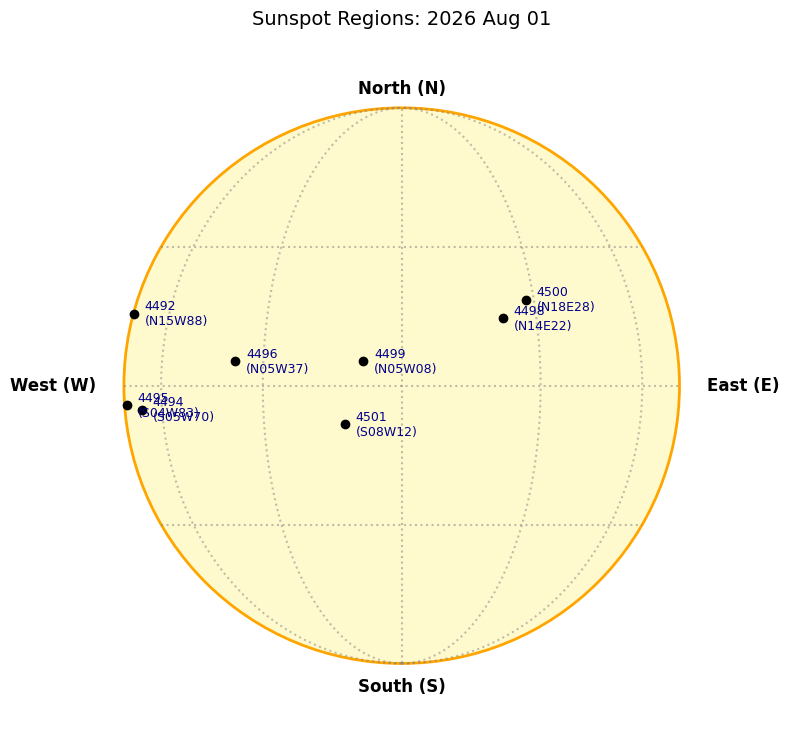

In [1]:
# SRSの黒点データから光球を模した円内に黒点群をプロットできる。
import requests
import re
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# ==========================================
# 1. 設定：ここに解析したいデータのURLを入力してください
# ==========================================
# 欲しい日分のデータを手に入れるときは欲しい日付にする(9月8日なら四桁を0908にする)
target_url = "https://sohoftp.nascom.nasa.gov/sdb/ydb/raw/selsis_regions/0801SRS.txt"

# ==========================================
# 2. データ解析用関数
# ==========================================
def parse_srs_for_plot(url):
    """SRSデータを取得し、プロット用に黒点番号と緯度経度を抽出する"""
    print(f"データを取得中: {url}")
    try:
        response = requests.get(url)
        response.raise_for_status()
        lines = response.text.splitlines()
    except Exception as e:
        print(f"エラーが発生しました: {e}")
        return [], None

    sunspots = []
    date_str = "Unknown Date"

    in_section_i = False

    for line in lines:
        # 日付の取得
        if ":Issued:" in line:
            date_str = " ".join(line.split()[1:4])

        # セクション判定
        if line.startswith("I.  Regions with Sunspots") or line.startswith("I. Regions with Sunspots"):
            in_section_i = True
            continue
        if in_section_i and (line.startswith("IA.") or line.startswith("II.") or line.strip() == ""):
             if line.startswith("IA.") or line.startswith("II."):
                 in_section_i = False
                 break

        # 座標データの抽出
        if in_section_i:
            parts = line.split()
            # Nmbr Location ... の形式 (例: 3654 N10W25 ...)
            if len(parts) > 2 and parts[0].isdigit():
                nmbr = parts[0]
                loc_str = parts[1] # 例: N10W25

                # 正規表現で分解 (N/S, 緯度, E/W, 経度)
                match = re.match(r'([NS])(\d+)([EW])(\d+)', loc_str)
                if match:
                    lat_dir, lat_val, lon_dir, lon_val = match.groups()

                    # 緯度の数値化 (北+ 南-)
                    lat = int(lat_val) if lat_dir == 'N' else -int(lat_val)

                    # 経度の数値化 (西+, 東- ) ※太陽面座標の慣習
                    # 地球から見て 西(West)は左側、東(East)は右側
                    lon = -int(lon_val) if lon_dir == 'W' else int(lon_val)

                    sunspots.append({
                        'nmbr': nmbr,
                        'loc_str': loc_str,
                        'lat': lat,
                        'lon': lon
                    })

    return sunspots, date_str

# ==========================================
# 3. プロット用関数 (正射図法: Orthographic Projection)
# ==========================================
def plot_sunspots_on_disk(sunspots, date_str):
    if not sunspots:
        print("プロットする黒点データが見つかりませんでした。")
        return

    fig, ax = plt.subplots(figsize=(8, 8))

    # --- 太陽の円盤を描画 ---
    # 半径1の円
    sun_disk = patches.Circle((0, 0), radius=1.0, edgecolor='orange', facecolor='#FFFACD', linewidth=2)
    ax.add_patch(sun_disk)

    # --- 緯線・経線のガイドラインを描画 (簡易的) ---
    # 緯線 (Latitude)
    x_range = np.linspace(-1, 1, 100)
    for lat_deg in [-30, 0, 30]:
        lat_rad = np.radians(lat_deg)
        # y = sin(lat) は直交射影では一定に見えるが、球体感を出すためXの範囲を制限
        # x^2 + y^2 = 1 => x limit depends on y
        y_val = np.sin(lat_rad)
        limit_x = np.cos(lat_rad)
        x_line = np.linspace(-limit_x, limit_x, 100)
        ax.plot(x_line, [y_val]*100, color='gray', linestyle=':', alpha=0.5)

    # 経線 (Longitude)
    y_range = np.linspace(-1, 1, 100)
    for lon_deg in [-60, -30, 0, 30, 60]:
        lon_rad = np.radians(lon_deg)
        # x = sin(lon) * cos(lat)
        # y = sin(lat)
        # これをパラメトリックに描画
        lats = np.linspace(-np.pi/2, np.pi/2, 100)
        x_line = np.sin(lon_rad) * np.cos(lats)
        y_line = np.sin(lats)
        ax.plot(x_line, y_line, color='gray', linestyle=':', alpha=0.5)

    # --- 黒点のプロット ---
    print(f"\n--- {date_str} の黒点リスト ---")
    for spot in sunspots:
        lat_rad = np.radians(spot['lat'])
        lon_rad = np.radians(spot['lon'])

        # 正射図法 (Orthographic Projection) への変換
        # 地球から見た平面座標 (x, y)
        # x = cos(lat) * sin(lon)
        # y = sin(lat)
        # ※太陽の傾き(B0)は0と仮定した簡易モデルです

        x = np.cos(lat_rad) * np.sin(lon_rad)
        y = np.sin(lat_rad)

        # 点をプロット
        ax.plot(x, y, marker='o', color='black', markersize=6)

        # テキスト表示 (少しずらして表示)
        label = f"{spot['nmbr']}\n({spot['loc_str']})"
        ax.text(x + 0.04, y, label, fontsize=9, color='darkblue', verticalalignment='center')

        print(f"Region {spot['nmbr']}: {spot['loc_str']} -> (x={x:.2f}, y={y:.2f})")

    # --- 方位と装飾 ---
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.axis('off') # 軸の数値を消す

    # 方位ラベル (太陽観測における方位)
    # 天球上では、北を上にして左が東、右が西、しかしながら観測時には投影板に映っているものを解析するため光球の東西は逆となる。
    ax.text(0, 1.05, 'North (N)', ha='center', fontsize=12, fontweight='bold')
    ax.text(0, -1.1, 'South (S)', ha='center', fontsize=12, fontweight='bold')
    ax.text(-1.1, 0, 'West (W)', va='center', ha='right', fontsize=12, fontweight='bold')
    ax.text(1.1, 0, 'East (E)', va='center', ha='left', fontsize=12, fontweight='bold')

    plt.title(f"Sunspot Regions: {date_str}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 実行
# ==========================================
spots_data, date_info = parse_srs_for_plot(target_url)
plot_sunspots_on_disk(spots_data, date_info)

In [3]:
# 指定した期間の黒点群の動きをSRSのデータをもとにして動画にできる。
import requests
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation
from IPython.display import HTML

# ==========================================
# 1. 設定：期間を指定してください
# ==========================================
# フォーマット: 'YYYY-MM-DD'
START_DATE = '2026-07-01'
END_DATE   = '2026-08-01'

BASE_URL = "https://sohoftp.nascom.nasa.gov/sdb/ydb/raw/selsis_regions/"

# ==========================================
# 2. データ取得・解析クラス
# ==========================================
class SunspotDataManager:
    def __init__(self, start_date, end_date):
        self.date_range = pd.date_range(start=start_date, end=end_date)
        self.data_cache = {} # {date_obj: [spots_list]}

    def fetch_all_data(self):
        print(f"{len(self.date_range)}日分のデータを取得・解析中...")

        for current_date in self.date_range:
            # URL生成: MMDDSRS.txt (例: 0427SRS.txt)
            file_name = current_date.strftime('%m%dSRS.txt')
            url = BASE_URL + file_name

            spots = self._parse_url(url)
            self.data_cache[current_date] = spots

        print("データ取得完了。アニメーションを作成します。")

    def _parse_url(self, url):
        try:
            response = requests.get(url, timeout=5)
            if response.status_code != 200:
                return [] # データなし

            lines = response.text.splitlines()
            spots = []
            in_section_i = False

            for line in lines:
                if line.startswith("I.  Regions with Sunspots") or line.startswith("I. Regions with Sunspots"):
                    in_section_i = True
                    continue
                if in_section_i and (line.startswith("IA.") or line.startswith("II.") or line.strip() == ""):
                     if line.startswith("IA.") or line.startswith("II."):
                         in_section_i = False
                         break

                if in_section_i:
                    parts = line.split()
                    if len(parts) > 2 and parts[0].isdigit():
                        nmbr = parts[0]
                        loc_str = parts[1] # N10W25

                        match = re.match(r'([NS])(\d+)([EW])(\d+)', loc_str)
                        if match:
                            lat_dir, lat_val, lon_dir, lon_val = match.groups()
                            lat = int(lat_val) if lat_dir == 'N' else -int(lat_val)
                            # 地球から見て 西(右)がプラス、東(左)がマイナス
                            lon = int(lon_val) if lon_dir == 'W' else -int(lon_val)

                            spots.append({'nmbr': nmbr, 'loc_str': loc_str, 'lat': lat, 'lon': lon})
            return spots

        except Exception:
            return []

# ==========================================
# 3. アニメーション描画設定
# ==========================================
def create_sunspot_animation(manager):
    fig, ax = plt.subplots(figsize=(6, 6))

    def init():
        return update(manager.date_range[0])

    def update(current_date):
        ax.clear()

        # --- 背景：太陽円盤 ---
        sun_disk = patches.Circle((0, 0), radius=1.0, edgecolor='orange', facecolor='#FFFACD', linewidth=2)
        ax.add_patch(sun_disk)

        # --- 背景：緯線・経線 ---
        # 緯線
        for lat_deg in [-30, 0, 30]:
            lat_rad = np.radians(lat_deg)
            y_val = np.sin(lat_rad)
            limit_x = np.cos(lat_rad)
            x_line = np.linspace(-limit_x, limit_x, 50)
            ax.plot(x_line, [y_val]*50, color='gray', linestyle=':', alpha=0.3)
        # 経線
        lats = np.linspace(-np.pi/2, np.pi/2, 50)
        for lon_deg in [-60, -30, 0, 30, 60]:
            lon_rad = np.radians(lon_deg)
            x_line = np.sin(lon_rad) * np.cos(lats)
            y_line = np.sin(lats)
            ax.plot(x_line, y_line, color='gray', linestyle=':', alpha=0.3)

        # --- 黒点プロット ---
        spots = manager.data_cache.get(current_date, [])

        # 日付表示
        date_str = current_date.strftime('%Y-%m-%d')
        ax.set_title(f"Sunspot Activity: {date_str}", fontsize=14, pad=10)

        if not spots:
            ax.text(0, 0, "No Data / No Spots", ha='center', color='gray')
        else:
            for spot in spots:
                lat_rad = np.radians(spot['lat'])
                lon_rad = np.radians(spot['lon'])

                # 正射図法変換
                x = np.cos(lat_rad) * np.sin(lon_rad)
                y = np.sin(lat_rad)

                # プロット
                ax.plot(x, y, marker='o', color='black', markersize=8)
                ax.text(x + 0.05, y, spot['nmbr'], fontsize=8, color='darkblue')

        # --- 方位・設定 ---
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_aspect('equal')
        ax.axis('off')

        # 方位ラベル
        ax.text(0, 1.05, 'N', ha='center', fontweight='bold')
        ax.text(0, -1.1, 'S', ha='center', fontweight='bold')
        ax.text(-1.1, 0, 'E', va='center', fontweight='bold')
        ax.text(1.1, 0, 'W', va='center', fontweight='bold')

    # アニメーション作成 (interval=1000ms = 1秒)
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=manager.date_range,
        init_func=None,
        interval=1000  # 1フレームの表示時間（ミリ秒）
    )

    plt.close() # 静止画の出力を防ぐ
    return ani

# ==========================================
# 4. 実行
# ==========================================
# マネージャー初期化
data_manager = SunspotDataManager(START_DATE, END_DATE)

# データ取得実行
data_manager.fetch_all_data()

# アニメーション生成
anim = create_sunspot_animation(data_manager)

# 動画として表示 (HTML5 Video)
HTML(anim.to_jshtml())

# MP4として保存する場合（ffmpegが必要です）
anim.save('sunspot_movie.mp4', writer='ffmpeg')

32日分のデータを取得・解析中...
データ取得完了。アニメーションを作成します。
